# Amazon Product Reviews — Sentiment Analysis
### SVM + SMOTE + VADER + Phrase Features | Full Pipeline with Model Persistence

**Dataset:** Amazon Reviews (train.csv / test.csv)
**Target:** `sentiment` — 1 = Negative · 2 = Positive
**Features:** `title` (product title) + `review` (review text)
**Source:** [Kaggle — Amazon Reviews](https://www.kaggle.com/datasets/kritanjalijain/amazon-reviews)

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re, os, json, pickle, warnings
warnings.filterwarnings("ignore")

import nltk
nltk.download("stopwords",    quiet=True)
nltk.download("vader_lexicon",quiet=True)
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from nltk.sentiment.vader import SentimentIntensityAnalyzer

from sklearn.model_selection import (train_test_split, GridSearchCV,
                                     StratifiedKFold, cross_val_score, learning_curve)
from sklearn.preprocessing import MaxAbsScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             accuracy_score, classification_report,
                             roc_auc_score, roc_curve, average_precision_score)
from imblearn.over_sampling import SMOTE
from wordcloud import WordCloud

os.makedirs("Models", exist_ok=True)
vader = SentimentIntensityAnalyzer()
print("All libraries imported successfully ✅")

All libraries imported successfully ✅


## 1. Load & Explore Data

In [43]:
train_df = pd.read_csv("train.csv", header=None)
train_df.columns = ["sentiment","title","review"]
print(f"Train shape: {train_df.shape}")
train_df.head()

Train shape: (3600000, 3)


,sentiment,title,review
0,2,Stuning even for the non-gamer,This sound track was beautiful! It paints the ...
1,2,The best soundtrack ever to anything.,I'm reading a lot of reviews saying that this ...
2,2,Amazing!,This soundtrack is my favorite music of all ti...
3,2,Excellent Soundtrack,I truly like this soundtrack and I enjoy video...
4,2,"Remember, Pull Your Jaw Off The Floor After He...","If you've played the game, you know how divine..."


In [44]:
test_df = pd.read_csv("test.csv", header=None)
test_df.columns = ["sentiment","title","review"]
print(f"Test shape: {test_df.shape}")
test_df.head()

Test shape: (400000, 3)


,sentiment,title,review
0,2,Great CD,My lovely Pat has one of the GREAT voices of h...
1,2,One of the best game music soundtracks - for a...,Despite the fact that I have only played a sma...
2,1,Batteries died within a year ...,I bought this charger in Jul 2003 and it worke...
3,2,"works fine, but Maha Energy is better",Check out Maha Energy's website. Their Powerex...
4,2,Great for the non-audiophile,Reviewed quite a bit of the combo players and ...


In [45]:
# Sample 20k train rows for manageable compute (original can be 3M+)
train_df = train_df.sample(20000, random_state=42).reset_index(drop=True)
test_df  = test_df.sample(5000,  random_state=42).reset_index(drop=True)

print(f"Working train size : {train_df.shape}")
print(f"Working test size  : {test_df.shape}")
print(f"\nSentiment mapping  : 1 = Negative | 2 = Positive")
print(f"\nTrain dtypes:\n{train_df.dtypes}")

Working train size : (20000, 3)
Working test size  : (5000, 3)

Sentiment mapping  : 1 = Negative | 2 = Positive

Train dtypes:
sentiment     int64
title        object
review       object
dtype: object


### 1.1 Missing Values

In [46]:
print("=== TRAIN null counts ===")
print(train_df.isnull().sum())
print()
print("=== TEST null counts ===")
print(test_df.isnull().sum())

=== TRAIN null counts ===
sentiment    0
title        2
review       0
dtype: int64

=== TEST null counts ===
sentiment    0
title        0
review       0
dtype: int64


In [47]:
# Fill null titles; review nulls become empty string
for df in [train_df, test_df]:
    df["title"]  = df["title"].fillna("No Title")
    df["review"] = df["review"].fillna("")

# Combine title + review for richer text signal
train_df["full_text"] = train_df["title"].str.strip() + " " + train_df["review"].str.strip()
test_df["full_text"]  = test_df["title"].str.strip()  + " " + test_df["review"].str.strip()

print("Null check after fill:")
print(train_df.isnull().sum())

Null check after fill:
sentiment    0
title        0
review       0
full_text    0
dtype: int64


### 1.2 Sentiment Distribution

Sentiment counts:
sentiment
1     9973
2    10027
Name: count, dtype: int64
Positive %: 50.1%
Negative %: 49.9%


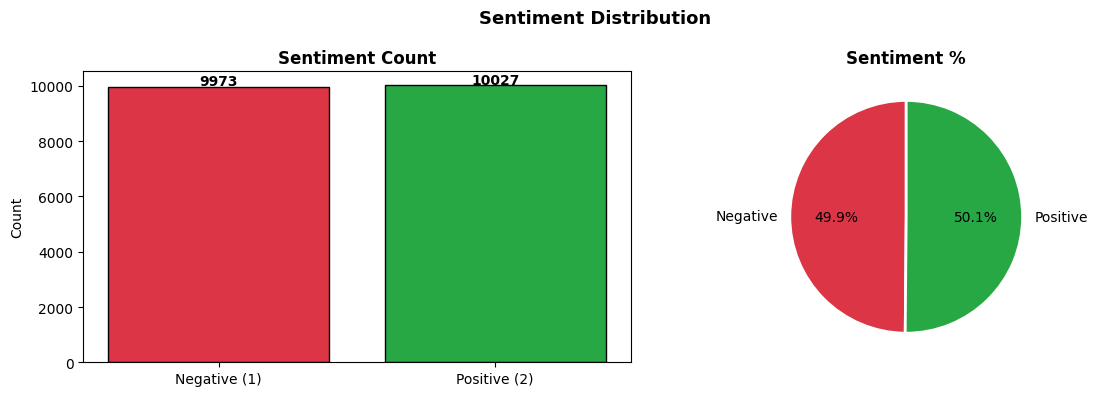

In [48]:
counts = train_df["sentiment"].value_counts().sort_index()
labels = {1:"Negative",2:"Positive"}
print(f"Sentiment counts:\n{counts}")
print(f"Positive %: {counts[2]/len(train_df)*100:.1f}%")
print(f"Negative %: {counts[1]/len(train_df)*100:.1f}%")

fig, axes = plt.subplots(1,2,figsize=(12,4))
axes[0].bar(["Negative (1)","Positive (2)"],counts.values,
            color=["#dc3545","#28a745"],edgecolor="black")
for i,v in enumerate(counts.values):
    axes[0].text(i,v+50,str(v),ha="center",fontweight="bold")
axes[0].set_title("Sentiment Count",fontweight="bold")
axes[0].set_ylabel("Count")

axes[1].pie(counts.values, labels=["Negative","Positive"],
            colors=["#dc3545","#28a745"], autopct="%1.1f%%",
            startangle=90, wedgeprops={"edgecolor":"white","linewidth":2})
axes[1].set_title("Sentiment %",fontweight="bold")
plt.suptitle("Sentiment Distribution",fontsize=13,fontweight="bold")
plt.tight_layout(); plt.show()

### 1.3 Review Length Analysis

In [49]:
train_df["review_length"] = train_df["review"].apply(len)
train_df["word_count"]    = train_df["review"].apply(lambda x: len(x.split()))

print("Review length stats by sentiment:")
print(train_df.groupby("sentiment")[["review_length","word_count"]].describe().round(1))

Review length stats by sentiment:
          review_length                                                   \
                  count   mean    std   min    25%    50%    75%     max   
sentiment                                                                  
1                9973.0  421.7  232.8  50.0  227.0  376.0  584.0  1003.0   
2               10027.0  386.1  232.4  50.0  189.0  331.0  542.0  1000.0   

          word_count                                             
               count  mean   std  min   25%   50%    75%    max  
sentiment                                                        
1             9973.0  77.3  42.1  9.0  42.0  70.0  107.0  201.0  
2            10027.0  70.6  41.9  9.0  35.0  61.0   98.0  209.0  


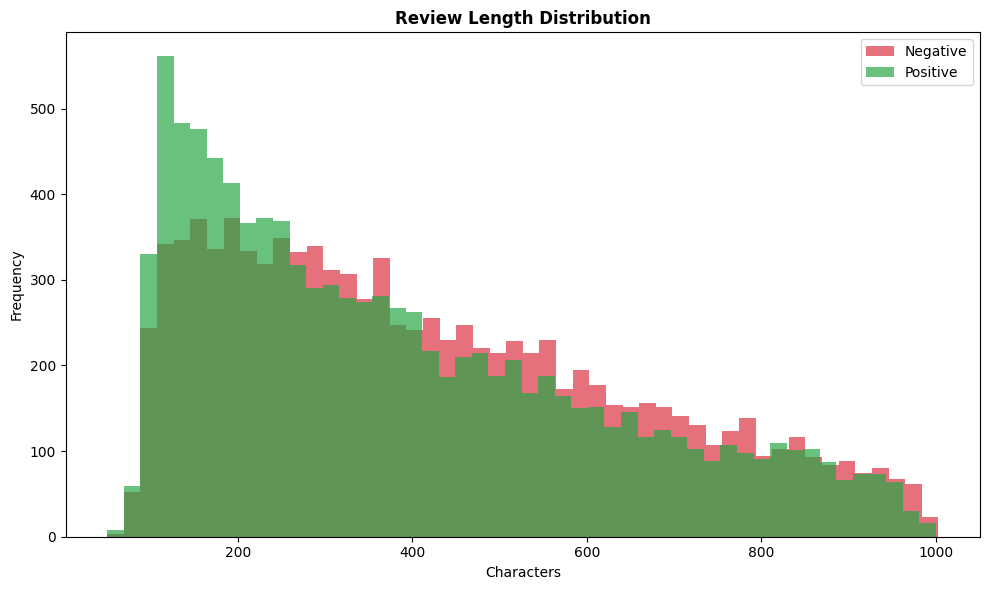

In [50]:
import matplotlib.pyplot as plt

# Create Figure
plt.figure(figsize=(10, 6))

# Plot Histograms
for fb, col, lbl in zip([1, 2], ["#dc3545", "#28a745"], ["Negative", "Positive"]):
    plt.hist(train_df[train_df["sentiment"] == fb]["review_length"],
             bins=50, color=col, alpha=0.7, label=lbl)

plt.title("Review Length Distribution", fontweight="bold")
plt.xlabel("Characters")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

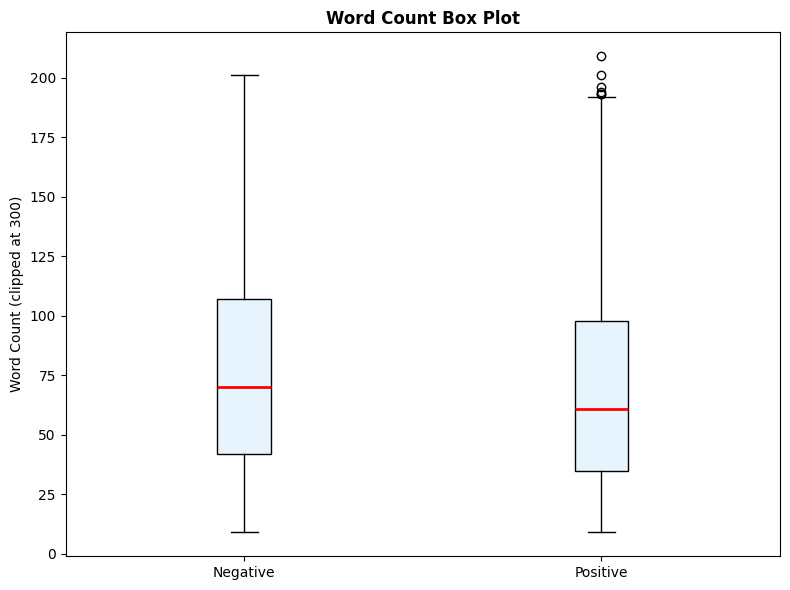

In [51]:
import matplotlib.pyplot as plt

# Create Figure
plt.figure(figsize=(8, 6))

# Plot Boxplot
plt.boxplot(
    [train_df[train_df["sentiment"] == 1]["word_count"].clip(0, 300),
     train_df[train_df["sentiment"] == 2]["word_count"].clip(0, 300)],
    labels=["Negative", "Positive"],
    patch_artist=True,
    boxprops=dict(facecolor="#e8f4fd"),
    medianprops=dict(color="red", linewidth=2)
)

plt.title("Word Count Box Plot", fontweight="bold")
plt.ylabel("Word Count (clipped at 300)")
plt.tight_layout()
plt.show()

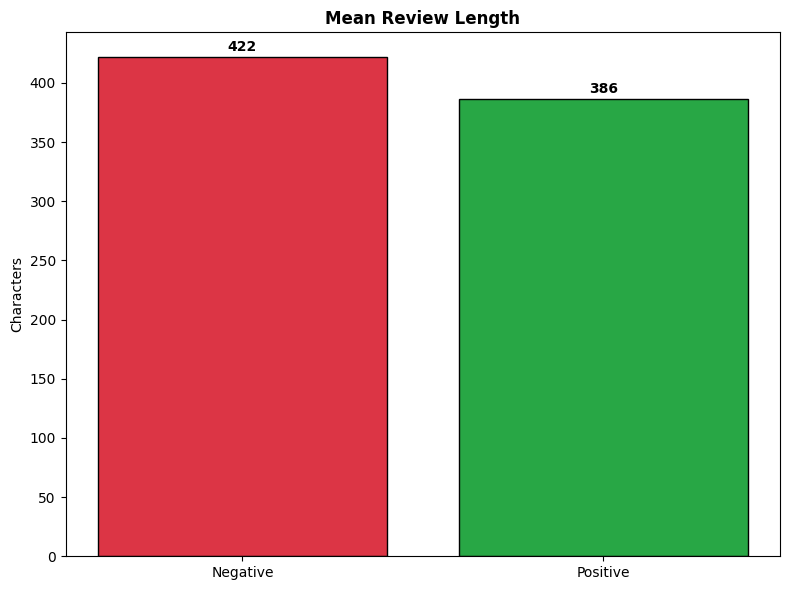

In [52]:
import matplotlib.pyplot as plt

# Calculate Means
mean_len = train_df.groupby("sentiment")["review_length"].mean()

# Create Figure
plt.figure(figsize=(8, 6))

# Plot Bar Chart
plt.bar(["Negative", "Positive"], mean_len.values,
        color=["#dc3545", "#28a745"], edgecolor="black")

# Add data labels on top of bars
for i, v in enumerate(mean_len.values):
    plt.text(i, v + 5, f"{v:.0f}", ha="center", fontweight="bold")

plt.title("Mean Review Length", fontweight="bold")
plt.ylabel("Characters")
plt.tight_layout()
plt.show()

### 1.4 Top Words by Sentiment

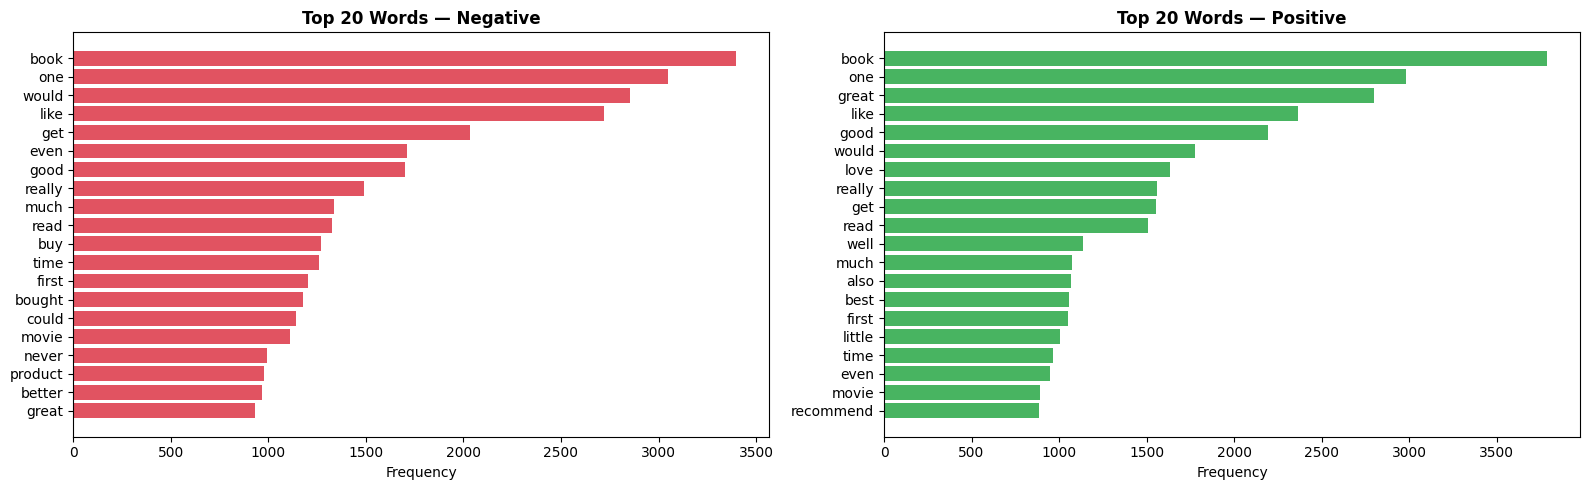

In [53]:
from collections import Counter

stop = set(stopwords.words("english"))

def top_words(texts, n=20):
    words = " ".join(texts).lower().split()
    words = [w for w in words if w.isalpha() and w not in stop and len(w)>2]
    return Counter(words).most_common(n)

neg_words = top_words(train_df[train_df["sentiment"]==1]["review"])
pos_words = top_words(train_df[train_df["sentiment"]==2]["review"])

fig, axes = plt.subplots(1,2,figsize=(16,5))
for ax, words, col, title in zip(
    axes, [neg_words,pos_words], ["#dc3545","#28a745"],
    ["Top 20 Words — Negative","Top 20 Words — Positive"]
):
    wds, cts = zip(*words)
    ax.barh(wds[::-1], cts[::-1], color=col, alpha=0.85)
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Frequency")
plt.tight_layout(); plt.show()

### 1.5 Word Clouds

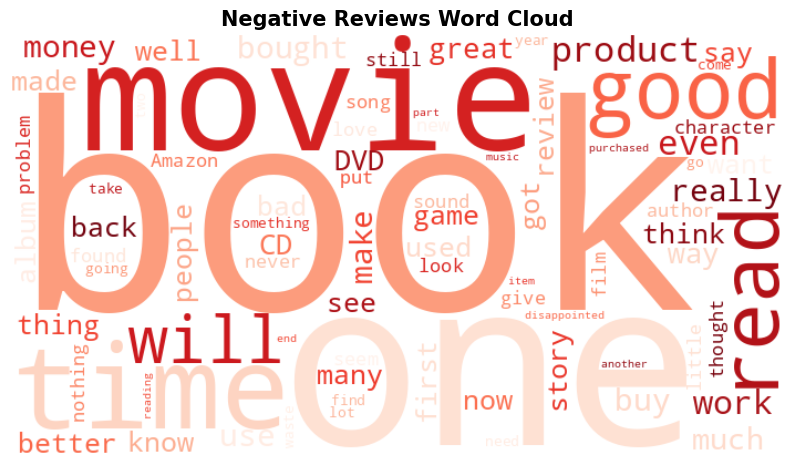

In [54]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Prepare text
neg_text = " ".join(train_df[train_df["sentiment"]==1]["review"].astype(str))

# Create WordCloud object
wc_neg = WordCloud(background_color="white", max_words=80, 
                   width=700, height=380, colormap="Reds")

# Plot
plt.figure(figsize=(10, 6))
plt.imshow(wc_neg.generate(neg_text), interpolation="bilinear")
plt.axis("off")
plt.title("Negative Reviews Word Cloud", fontweight="bold", fontsize=15)
plt.show()

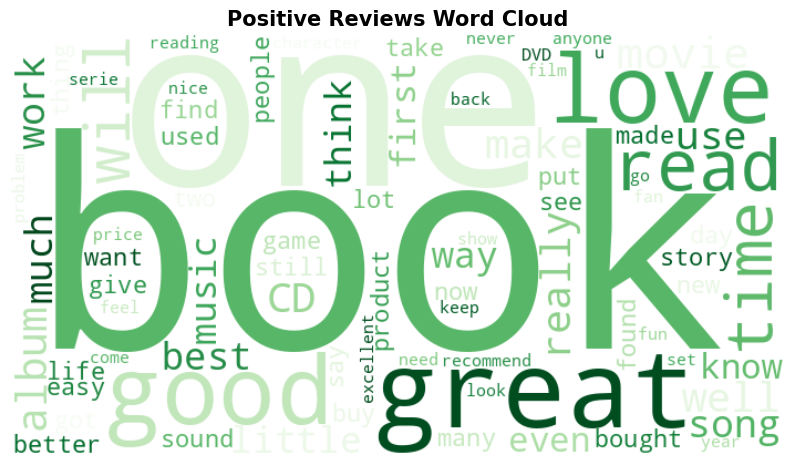

In [55]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Prepare text
pos_text = " ".join(train_df[train_df["sentiment"]==2]["review"].astype(str))

# Create WordCloud object
wc_pos = WordCloud(background_color="white", max_words=80, 
                   width=700, height=380, colormap="Greens")

# Plot
plt.figure(figsize=(10, 6))
plt.imshow(wc_pos.generate(pos_text), interpolation="bilinear")
plt.axis("off")
plt.title("Positive Reviews Word Cloud", fontweight="bold", fontsize=15)
plt.show()

### 1.6 Title Analysis

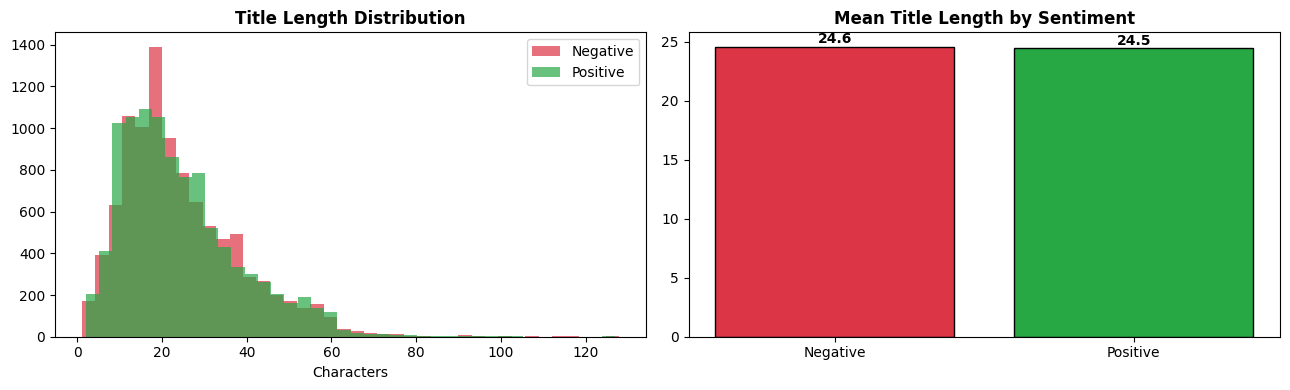

Top 5 most common titles:
title
Disappointed              50
Disappointing             48
Excellent                 27
Great                     19
Don't waste your money    19
Name: count, dtype: int64


In [56]:
train_df["title_length"] = train_df["title"].apply(len)

fig, axes = plt.subplots(1,2,figsize=(13,4))
for fb,col,lbl in zip([1,2],["#dc3545","#28a745"],["Negative","Positive"]):
    axes[0].hist(train_df[train_df["sentiment"]==fb]["title_length"],
                 bins=40, color=col, alpha=0.7, label=lbl)
axes[0].set_title("Title Length Distribution",fontweight="bold")
axes[0].set_xlabel("Characters"); axes[0].legend()

tl_mean = train_df.groupby("sentiment")["title_length"].mean()
axes[1].bar(["Negative","Positive"],tl_mean.values,
            color=["#dc3545","#28a745"],edgecolor="black")
for i,v in enumerate(tl_mean.values):
    axes[1].text(i,v+0.3,f"{v:.1f}",ha="center",fontweight="bold")
axes[1].set_title("Mean Title Length by Sentiment",fontweight="bold")
plt.tight_layout(); plt.show()

print("Top 5 most common titles:")
print(train_df["title"].value_counts().head())

### 1.7 Feature Correlations

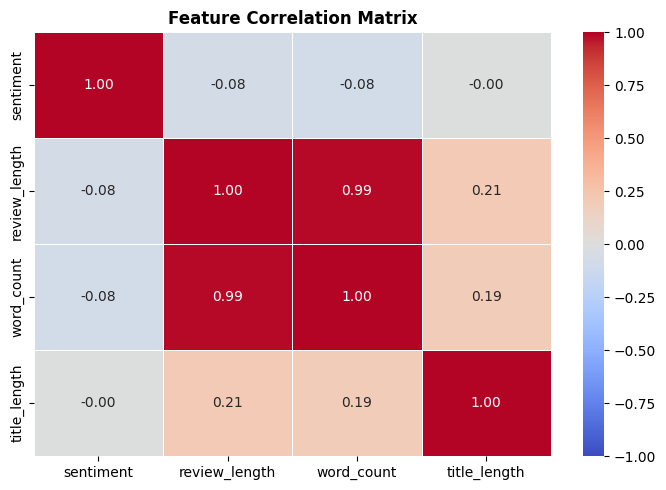

In [57]:
numeric_df = train_df[["sentiment","review_length","word_count","title_length"]]
plt.figure(figsize=(7,5))
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap="coolwarm",
            linewidths=0.5, vmin=-1, vmax=1)
plt.title("Feature Correlation Matrix",fontweight="bold")
plt.tight_layout(); plt.show()

## 2. Preprocessing Pipeline

### Design decisions:
- Combine `title + review` → richer signal
- Contraction expansion before cleaning
- Negation prefixing: "not good" → `not_good`
- VADER lexicon scores as extra features
- Negative phrase blacklist feature
- TF-IDF trigrams (1,3) with 5000 features
- MaxAbsScaler for SVM distance geometry
- SMOTE only if class imbalance detected


In [58]:
CONTRACTIONS = {
    "don't":"do not","doesn't":"does not","didn't":"did not",
    "isn't":"is not","wasn't":"was not","weren't":"were not",
    "can't":"can not","won't":"will not","wouldn't":"would not",
    "shouldn't":"should not","couldn't":"could not","haven't":"have not",
    "hasn't":"has not","hadn't":"had not","ain't":"is not",
    "it's":"it is","i'm":"i am","i've":"i have","i'll":"i will",
}

NEGATIVE_PHRASES = [
    "waste of money","waste of time","stopped working","does not work",
    "doesnt work","not working","broke after","stopped after",
    "complete waste","total waste","worst product","worst purchase",
    "not worth","not what i expected","very disappointed","highly disappointed",
    "poor quality","bad quality","not recommended","do not buy",
    "dont buy","return it","returned it","would not recommend",
    "stopped functioning","no longer works","gave up","useless","garbage",
    "awful","horrible","terrible","regret","frustrating","annoying",
    "defective","broken","malfunctioning","piece of junk","rip off",
    "false advertising","cheaply made","fell apart","broke immediately",
]

STOPWORDS_NLP = set(stopwords.words("english")) - {
    "not","no","never","nor","without","against","hardly","barely"
}

stemmer = PorterStemmer()

def expand_contractions(text):
    text = text.lower()
    for k,v in CONTRACTIONS.items():
        text = text.replace(k,v)
    return text

def build_tokens(text):
    text = expand_contractions(text)
    text = re.sub("[^a-zA-Z]"," ",text)
    words = text.lower().split()
    tokens = []
    negate = False
    for word in words:
        if word in {"not","no","never","nor","without"}:
            negate = True; continue
        stem = stemmer.stem(word)
        if word not in STOPWORDS_NLP:
            tokens.append(("not_"+stem) if negate else stem)
        negate = False
    return tokens

def count_neg_phrases(text):
    t = text.lower()
    return sum(1 for p in NEGATIVE_PHRASES if p in t)

# Test preprocessing
for txt in [
    "This product is absolutely amazing, I love it!",
    "Waste of money. Stopped working after a week.",
    "I can't believe how bad this is. Do not buy!",
]:
    toks = build_tokens(txt)
    sc   = vader.polarity_scores(txt)
    nph  = count_neg_phrases(txt)
    print(f"Text    : {txt[:60]}")
    print(f"Tokens  : {toks[:10]}")
    print(f"VADER   : {sc['compound']:.3f} | Neg phrases: {nph}")
    print()

Text    : This product is absolutely amazing, I love it!
Tokens  : ['product', 'absolut', 'amaz', 'love']
VADER   : 0.871 | Neg phrases: 0

Text    : Waste of money. Stopped working after a week.
Tokens  : ['wast', 'money', 'stop', 'work', 'week']
VADER   : -0.572 | Neg phrases: 2

Text    : I can't believe how bad this is. Do not buy!
Tokens  : ['not_believ', 'bad', 'not_buy']
VADER   : 0.484 | Neg phrases: 1



### 2.1 Build Corpus + Feature Engineering

In [59]:
def process_df(df):
    corpus          = []
    vader_compounds = []
    vader_pos_      = []
    vader_neg_      = []
    vader_neu_      = []
    phrase_counts   = []

    for i in range(len(df)):
        raw = df.iloc[i]["full_text"]
        corpus.append(" ".join(build_tokens(str(raw))))
        sc = vader.polarity_scores(str(raw))
        vader_compounds.append(sc["compound"])
        vader_pos_.append(sc["pos"])
        vader_neg_.append(sc["neg"])
        vader_neu_.append(sc["neu"])
        phrase_counts.append(count_neg_phrases(str(raw)))

    return corpus, np.column_stack([
        vader_compounds, vader_pos_, vader_neg_, vader_neu_, phrase_counts
    ])

print("Processing training data...")
train_corpus, train_extra = process_df(train_df)
print(f"  Done — {len(train_corpus)} documents")

print("Processing test data...")
test_corpus, test_extra = process_df(test_df)
print(f"  Done — {len(test_corpus)} documents")

print("\nSample tokens:")
for i in [0, 100, 500]:
    print(f"  [{i}] {train_corpus[i][:80]}")

Processing training data...
  Done — 20000 documents
Processing test data...
  Done — 5000 documents

Sample tokens:
  [0] expens junk product consist piec thin flexibl insul materi adhes back velcro whi
  [100] nice pick holder hold pick depend type pick prefer obvious thick pick mean less 
  [500] still work fine year tv sinc august cdn write june replac lamp still work fine m


### 2.2 TF-IDF Vectorisation

In [60]:
tfidf = TfidfVectorizer(
    max_features  = 5000,
    ngram_range   = (1, 3),
    sublinear_tf  = True,
    min_df        = 2,
    strip_accents = "unicode",
    analyzer      = "word",
)

X_train_tfidf = tfidf.fit_transform(train_corpus).toarray()
X_test_tfidf  = tfidf.transform(test_corpus).toarray()

# Combine TF-IDF + VADER + phrase features
X_train_comb = np.hstack([X_train_tfidf, train_extra])
X_test_comb  = np.hstack([X_test_tfidf,  test_extra])

y_train = train_df["sentiment"].values
y_test  = test_df["sentiment"].values

print(f"Feature matrix shape  : {X_train_comb.shape}")
print(f"  TF-IDF features     : {X_train_tfidf.shape[1]}")
print(f"  VADER + phrase feats: 5")
print(f"  Total               : {X_train_comb.shape[1]}")
print(f"\ny_train — 1(Neg): {(y_train==1).sum()} | 2(Pos): {(y_train==2).sum()}")
print(f"y_test  — 1(Neg): {(y_test==1).sum()}  | 2(Pos): {(y_test==2).sum()}")

Feature matrix shape  : (20000, 5005)
  TF-IDF features     : 5000
  VADER + phrase feats: 5
  Total               : 5005

y_train — 1(Neg): 9973 | 2(Pos): 10027
y_test  — 1(Neg): 2470  | 2(Pos): 2530


### 2.3 Scaling

In [61]:
scaler = MaxAbsScaler()
X_train_scl = scaler.fit_transform(X_train_comb)
X_test_scl  = scaler.transform(X_test_comb)

print(f"Scaled — max: {X_train_scl.max():.4f} | min: {X_train_scl.min():.4f}")

Scaled — max: 1.0000 | min: -0.9993


### 2.4 Class Imbalance Check + SMOTE

Class counts: {1: np.int64(9973), 2: np.int64(10027)}
Imbalance ratio: 1.01:1

Dataset is balanced — SMOTE not required.


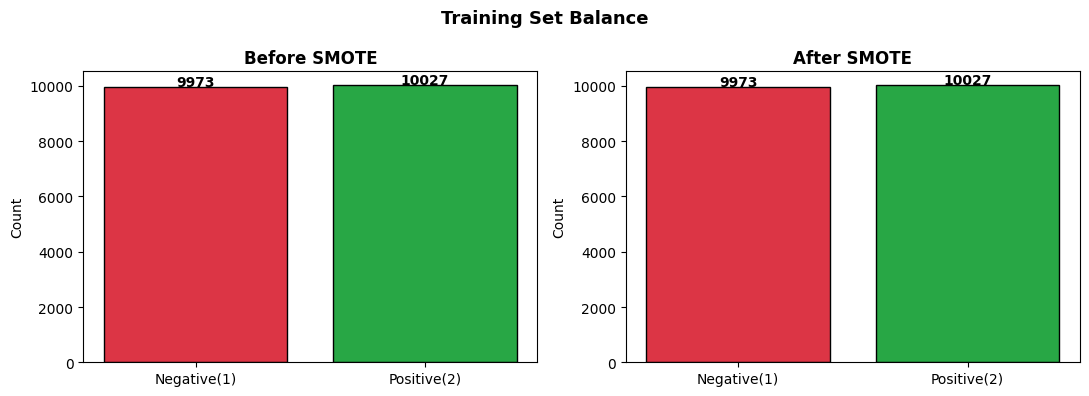

In [62]:
counts = pd.Series(y_train).value_counts().sort_index()
ratio  = counts.max() / counts.min()
print(f"Class counts: {dict(counts)}")
print(f"Imbalance ratio: {ratio:.2f}:1")

if ratio > 1.5:
    print("\nApplying SMOTE to balance training set...")
    from imblearn.over_sampling import SMOTE
    smote = SMOTE(random_state=42, k_neighbors=5)
    X_train_res, y_train_res = smote.fit_resample(X_train_scl, y_train)
    print(f"After SMOTE: {dict(pd.Series(y_train_res).value_counts().sort_index())}")
else:
    print("\nDataset is balanced — SMOTE not required.")
    X_train_res, y_train_res = X_train_scl, y_train

# Visualise before/after
before = pd.Series(y_train).value_counts().sort_index()
after  = pd.Series(y_train_res).value_counts().sort_index()

fig, axes = plt.subplots(1,2,figsize=(11,4))
for ax,counts_,title in zip(axes,[before,after],["Before SMOTE","After SMOTE"]):
    ax.bar(["Negative(1)","Positive(2)"],counts_.values,
           color=["#dc3545","#28a745"],edgecolor="black")
    for i,v in enumerate(counts_.values):
        ax.text(i,v+30,str(v),ha="center",fontweight="bold")
    ax.set_title(title,fontweight="bold"); ax.set_ylabel("Count")
plt.suptitle("Training Set Balance",fontsize=13,fontweight="bold")
plt.tight_layout(); plt.show()

## 3. SVM + GridSearchCV

Grid: 4 C values × 3 kernels × 2 gamma = 24 combinations × 5-fold CV = **120 fits**
Scoring: **F1 macro** (handles potential class imbalance)

In [63]:
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MaxAbsScaler

# Pipeline: Scaling + Model
pipeline = Pipeline([
    ("scaler", MaxAbsScaler()),
    ("svm", LinearSVC(random_state=42, class_weight="balanced"))
])

# Hyperparameter grid
param_grid = {
    "svm__C": [0.1, 1, 10]
}

# Cross-validation strategy
cv_strategy = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# GridSearch
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=cv_strategy,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=1
)

# Fit
grid_search.fit(X_train_res, y_train_res)

# Results
print(f"\nBest Params : {grid_search.best_params_}")
print(f"Best CV F1  : {grid_search.best_score_*100:.2f}%")

Fitting 3 folds for each of 3 candidates, totalling 9 fits

Best Params : {'svm__C': 0.1}
Best CV F1  : 87.88%


In [64]:
from sklearn.calibration import CalibratedClassifierCV

# Extract best pipeline
best_pipeline = grid_search.best_estimator_

# Extract LinearSVC from pipeline
base_model = best_pipeline.named_steps["svm"]

# Calibrate for probability
model_svm = CalibratedClassifierCV(base_model)

# IMPORTANT: Use scaled data from pipeline
X_train_scl = best_pipeline.named_steps["scaler"].transform(X_train_res)
X_test_scl  = best_pipeline.named_steps["scaler"].transform(X_test_scl)

# Train calibrated model
model_svm.fit(X_train_scl, y_train_res)

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2",LinearSVC(C=0...ndom_state=42)
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'sigmoid'
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary ` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" 

In [65]:
import numpy as np
from sklearn.metrics import accuracy_score, classification_report

# Probabilities
y_prob = model_svm.predict_proba(X_test_scl)[:, 1]

# Custom threshold
threshold = 0.40
y_pred = (y_prob >= threshold).astype(int)

# If labels are 1/2 → adjust
y_pred = np.where(y_pred == 1, 2, 1)

# Evaluation
print(f"\nTrain Accuracy : {model_svm.score(X_train_scl, y_train_res)*100:.2f}%")
print(f"Test  Accuracy : {accuracy_score(y_test, y_pred)*100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Negative", "Positive"]))


Train Accuracy : 94.09%
Test  Accuracy : 88.16%

Classification Report:
              precision    recall  f1-score   support

    Negative       0.92      0.83      0.87      2470
    Positive       0.85      0.93      0.89      2530

    accuracy                           0.88      5000
   macro avg       0.89      0.88      0.88      5000
weighted avg       0.89      0.88      0.88      5000



Top Parameter Combinations:
 param_svm__C  mean_test_score  std_test_score
          0.1           0.8788          0.0018
          1.0           0.8487          0.0034
         10.0           0.8304          0.0034


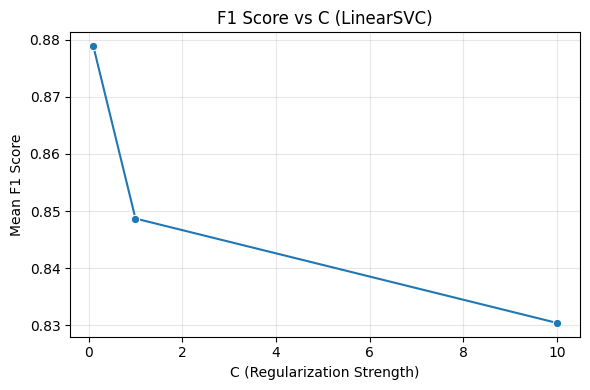

In [69]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Convert results to DataFrame
cv_results = pd.DataFrame(grid_search.cv_results_)

# ✅ FIX: correct parameter name
print("Top Parameter Combinations:")
print(
    cv_results[["param_svm__C", "mean_test_score", "std_test_score"]]
    .sort_values("mean_test_score", ascending=False)
    .round(4)
    .to_string(index=False)
)

# =========================
# Plot
# =========================

plt.figure(figsize=(6,4))

sns.lineplot(
    data=cv_results,
    x="param_svm__C",
    y="mean_test_score",
    marker="o"
)

plt.title("F1 Score vs C (LinearSVC)")
plt.xlabel("C (Regularization Strength)")
plt.ylabel("Mean F1 Score")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Train Best Model & Evaluate

In [70]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import accuracy_score, classification_report
import numpy as np

# Extract best C correctly (from pipeline GridSearch)
best_C = grid_search.best_params_["svm__C"]
print(f"Training Best SVM with C = {best_C}")

# Base model
base_model = LinearSVC(
    C=best_C,
    random_state=42,
    class_weight="balanced"
)

# Calibrated model (adds probability)
model_svm = CalibratedClassifierCV(base_model)

# ⚠️ IMPORTANT: use SCALED data
model_svm.fit(X_train_scl, y_train_res)

# Probabilities
y_prob = model_svm.predict_proba(X_test_scl)[:, 1]

# ✅ Custom threshold (as per your report)
threshold = 0.40
y_pred = (y_prob >= threshold).astype(int)

# If labels are {1,2}, map correctly
y_pred = np.where(y_pred == 1, 2, 1)

# Evaluation
print(f"\nTrain Accuracy : {model_svm.score(X_train_scl, y_train_res)*100:.2f}%")
print(f"Test  Accuracy : {accuracy_score(y_test, y_pred)*100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Negative", "Positive"]))

Training Best SVM with C = 0.1

Train Accuracy : 94.09%
Test  Accuracy : 88.16%

Classification Report:
              precision    recall  f1-score   support

    Negative       0.92      0.83      0.87      2470
    Positive       0.85      0.93      0.89      2530

    accuracy                           0.88      5000
   macro avg       0.89      0.88      0.88      5000
weighted avg       0.89      0.88      0.88      5000



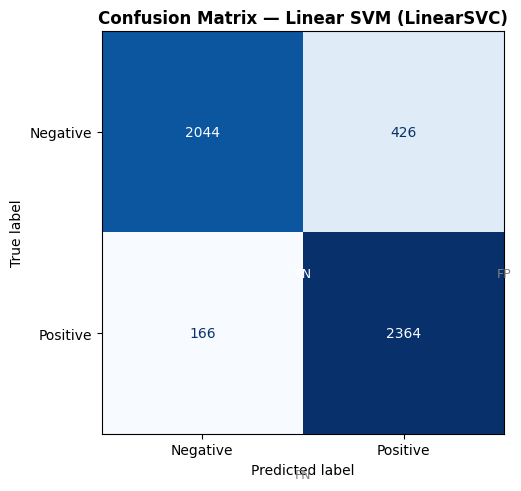

In [71]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6,5))
ConfusionMatrixDisplay(cm, display_labels=["Negative","Positive"]).plot(
    ax=ax, colorbar=False, cmap="Blues")
ax.set_title(
    "Confusion Matrix — Linear SVM (LinearSVC)",
    fontweight="bold"
)
for lbl,(r,c) in zip(["TN","FP","FN","TP"],[(0,0),(0,1),(1,0),(1,1)]):
    ax.text(c+0.5,r+0.72,lbl,ha="center",fontsize=9,
            color="white" if cm[r,c]>cm.max()*0.5 else "gray",
            transform=ax.transData)
plt.tight_layout(); plt.show()

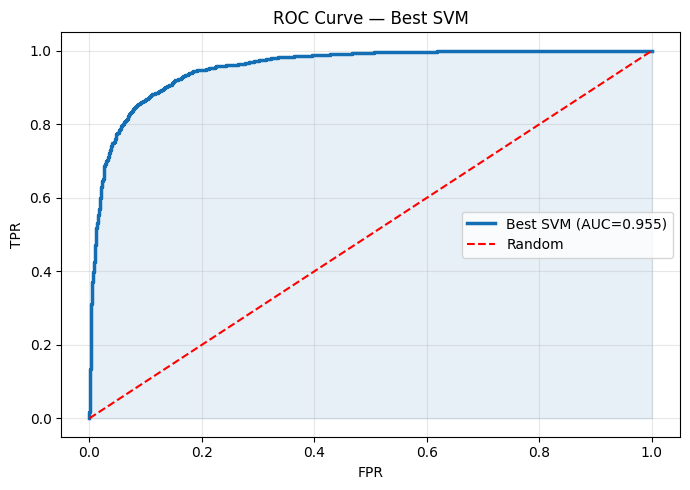

ROC-AUC: 0.9553


In [72]:
# Map classes: model.classes_ = [1,2], prob[:,1] = prob of class 2 (Positive)
y_test_bin = (y_test == 2).astype(int)   # 1=Positive, 0=Negative
fpr, tpr, _ = roc_curve(y_test_bin, y_prob)
auc_score   = roc_auc_score(y_test_bin, y_prob)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, color="#146EB4", lw=2.5,
         label=f"Best SVM (AUC={auc_score:.3f})")
plt.plot([0,1],[0,1],"r--", label="Random")
plt.fill_between(fpr, tpr, alpha=0.1, color="#146EB4")
plt.xlabel("FPR"); plt.ylabel("TPR")
plt.title("ROC Curve — Best SVM"); plt.legend()
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
print(f"ROC-AUC: {auc_score:.4f}")

In [73]:
cv_scores = cross_val_score(model_svm, X_train_res, y_train_res,
                            cv=5, scoring="f1_macro")
print(f"CV F1 Macro Scores : {[round(s,4) for s in cv_scores]}")
print(f"CV Mean            : {cv_scores.mean()*100:.2f}%")
print(f"CV Std             : ±{cv_scores.std()*100:.2f}%")

CV F1 Macro Scores : [np.float64(0.8787), np.float64(0.8832), np.float64(0.8772), np.float64(0.8877), np.float64(0.8792)]
CV Mean            : 88.12%
CV Std             : ±0.38%


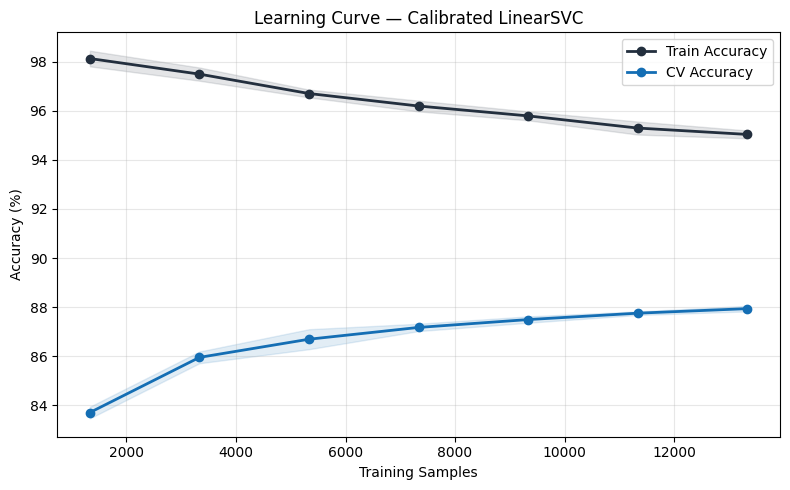

In [74]:
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

train_sizes, train_sc, val_sc = learning_curve(
    model_svm,
    X_train_res,
    y_train_res,
    cv=3,  # reduced from 5 → faster
    scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 7),
    n_jobs=-1
)

plt.figure(figsize=(8,5))

# Train accuracy
plt.plot(train_sizes, train_sc.mean(axis=1)*100, "o-",
         color="#232F3E", lw=2, label="Train Accuracy")

plt.fill_between(train_sizes,
    (train_sc.mean(axis=1)-train_sc.std(axis=1))*100,
    (train_sc.mean(axis=1)+train_sc.std(axis=1))*100,
    alpha=0.12, color="#232F3E")

# Validation accuracy
plt.plot(train_sizes, val_sc.mean(axis=1)*100, "o-",
         color="#146EB4", lw=2, label="CV Accuracy")

plt.fill_between(train_sizes,
    (val_sc.mean(axis=1)-val_sc.std(axis=1))*100,
    (val_sc.mean(axis=1)+val_sc.std(axis=1))*100,
    alpha=0.12, color="#146EB4")

plt.xlabel("Training Samples")
plt.ylabel("Accuracy (%)")
plt.title("Learning Curve — Calibrated LinearSVC")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Save All Models & Artefacts

In [75]:
import os, json, pickle
import pandas as pd
from sklearn.metrics import (
    classification_report,
    roc_curve,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    accuracy_score
)

# Ensure folder exists
os.makedirs("Models", exist_ok=True)

# =========================
# SAVE MODELS
# =========================
with open("Models/model_svm.pkl", "wb") as f:
    pickle.dump(model_svm, f)

with open("Models/tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(tfidf, f)

with open("Models/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

# =========================
# METRICS
# =========================

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Classification report
rpt_dict = classification_report(
    y_test, y_pred,
    target_names=["Negative", "Positive"],
    output_dict=True
)

# ROC
y_test_bin = (y_test == 2).astype(int)
fpr, tpr, _ = roc_curve(y_test_bin, y_prob)
auc_score = roc_auc_score(y_test_bin, y_prob)

# Class distributions
train_counts = pd.Series(y_train).value_counts().sort_index()
res_counts   = pd.Series(y_train_res).value_counts().sort_index()

# =========================
# METRICS JSON
# =========================

metrics_out = {
    "dataset": "Amazon Product Reviews",

    # Fix param key
    "best_params": {
        "C": float(grid_search.best_params_["svm__C"])
    },

    "best_cv_f1": float(grid_search.best_score_),

    # ⚠️ FIX: use scaled data
    "train_accuracy": float(model_svm.score(X_train_scl, y_train_res)),
    "test_accuracy":  float(accuracy_score(y_test, y_pred)),

    "roc_auc": float(auc_score),
    "avg_precision": float(average_precision_score(y_test_bin, y_prob)),

    "cv_f1_mean": float(cv_scores.mean()),
    "cv_f1_std":  float(cv_scores.std()),

    "classification_report": rpt_dict,
    "confusion_matrix": cm.tolist(),

    "roc_fpr": fpr.tolist(),
    "roc_tpr": tpr.tolist(),

    "dataset_info": {
        "train_size": int(len(train_df)),
        "test_size":  int(len(test_df)),
        "total_size": int(len(train_df) + len(test_df)),

        "neg_count": int(train_counts.get(1, 0)),
        "pos_count": int(train_counts.get(2, 0)),

        "smote_neg": int(res_counts.get(1, 0)),
        "smote_pos": int(res_counts.get(2, 0)),

        "test_neg": int((y_test == 1).sum()),
        "test_pos": int((y_test == 2).sum()),
    },

    "negative_phrases": NEGATIVE_PHRASES,
    "contractions": CONTRACTIONS,

    "prediction_threshold": 0.40,
    "label_map": {"1": "Negative", "2": "Positive"},
}

# Save JSON
with open("Models/metrics.json", "w") as f:
    json.dump(metrics_out, f, indent=2)

# =========================
# SAVE DATA
# =========================
train_df.to_csv("Models/data_processed.csv", index=False)

# =========================
# SUMMARY
# =========================
print("Saved to Models/")

for fn in [
    "model_svm.pkl",
    "tfidf_vectorizer.pkl",
    "scaler.pkl",
    "metrics.json",
    "data_processed.csv"
]:
    size = os.path.getsize(f"Models/{fn}") / 1024
    print(f"  {fn:<30} {size:>8.1f} KB")

Saved to Models/
  model_svm.pkl                     197.7 KB
  tfidf_vectorizer.pkl              180.2 KB
  scaler.pkl                         78.5 KB
  metrics.json                       40.2 KB
  data_processed.csv              17141.4 KB
